In [ ]:
from geostat_isoscapes_tools import geostat_utils as gutils, plot_utils as putils, sisal_utils as sutils, utils
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd 
import json
import os 
sns.set_style('dark')

In this notebook, we compare variograms of itrace and sisal data. In particular, we select itrace data with the union of circles centered around sisal points at each time slice.

Hence, we developped a function that automatically defines the mask, compute sisal and itrace variograms and save the results.

In [23]:
params = {'trend': 'multiple_linear_ele_lat_abs',
          'trend_before_mask': True,
          'maxlag': 1.2e7,
          'nlags': 15,
          'centers': None,
          'direction': None,
          'tolerance':11.5,
          'mask radius [km]': 500,
          'res [jours]': 100*365,
          'Itrace simulation spec' : {'time':'20kyrBP',},
          'countries':None
          }
data_cols = {'lat':'lat',
             'lon':'lon',
             'quantity':'d18Op'}

fp = f"../output/variograms/itrace/sim{params['Itrace simulation spec']['time']}/res{params['res [jours]']}/maxlag{str(int(params['maxlag']))}nlags{params['nlags']}/trend_{params['trend']}/"
if not os.path.exists(fp) :
    os.makedirs(fp)

verbose =  False

In [20]:
# Load sisal data 
sisal_df = gutils.get_sisal_data_for_kriging(res=int(params['res [jours]']/365),countries=params['countries'],verbose=verbose)
# load itrace data
itrace_data = gutils.preprocessed_itrace_data(res=params['res [jours]'],P=True,format='xr',verbose=False) # xr


loading sisal data
sisal dataframe is ready
loading itrace files


#### **Mask iTrace data around SISAL points**

In [24]:
itrace_df = gutils.preprocessed_itrace_data(res=params['res [jours]'],P=True,format='df',verbose=False) # df

loading itrace files
done


In [25]:
itrace_masked_df,_ = utils.mask_union_of_circles_around_pts(itrace_df,sisal_df,params['mask radius [km]']) # type:ignore
putils.plot_global_map(data=itrace_masked_df,
                    quantity_col=data_cols['quantity'],
                    title = 'masked itrace data',
                    quantity=data_cols['quantity'],
                    unit='per mil (VSMOW)',
                    proj=True,
                    symbol='square',
                    size=3,
                    lat_col=data_cols['lat'],
                    lon_col=data_cols['lon'])

#### **Compute variograms**

In [26]:
for azimuth in [None,0,45,90,135] : 
    print(f'computation dir={azimuth}')
    params['direction']=azimuth
    gutils.iterate_and_aggregate_variograms(data_ds = itrace_data, #type:ignore
                                        fp=fp,
                                        config_dict=params,
                                        data_cols=data_cols,
                                        mask_pts = sisal_df, # type:ignore
                                        verbose = verbose
                                       )

computation dir=None


100%|██████████| 7/7 [00:06<00:00,  1.16it/s]


outputs saved in folder ../output/variograms/itrace/sim20kyrBP/res36500/maxlag12000000nlags15/trend_multiple_linear_ele_lat_abs/, files vario_df.csv and trend_metrics.json
computation dir=0


100%|██████████| 7/7 [00:41<00:00,  5.97s/it]


outputs saved in folder ../output/variograms/itrace/sim20kyrBP/res36500/maxlag12000000nlags15/trend_multiple_linear_ele_lat_abs/d0, files vario_df.csv and trend_metrics.json
computation dir=45


...

outputs saved in folder ../output/variograms/itrace/sim20kyrBP/res36500/maxlag12000000nlags15/trend_multiple_linear_ele_lat_abs/d45, files vario_df.csv and trend_metrics.json
computation dir=90


100%|██████████| 7/7 [00:47<00:00,  6.76s/it]


outputs saved in folder ../output/variograms/itrace/sim20kyrBP/res36500/maxlag12000000nlags15/trend_multiple_linear_ele_lat_abs/d90, files vario_df.csv and trend_metrics.json
computation dir=135


100%|██████████| 7/7 [00:41<00:00,  5.93s/it]

outputs saved in folder ../output/variograms/itrace/sim20kyrBP/res36500/maxlag12000000nlags15/trend_multiple_linear_ele_lat_abs/d135, files vario_df.csv and trend_metrics.json


In [27]:
dict_dfs= {
           'i_all': {'df': pd.read_csv(fp+'vario_df.csv')},
           'i_0': {'df': pd.read_csv(fp+'d0vario_df.csv')},
           'i_45': {'df': pd.read_csv(fp+'d45vario_df.csv')},
           'i_90': {'df': pd.read_csv(fp+'d90vario_df.csv')},
           'i_135': {'df': pd.read_csv(fp+'d135vario_df.csv')}
        }

model_name = 'spherical'

for key in dict_dfs.keys():
    dict_dfs[key]['params'],dict_dfs[key]['fct_fitted'],dict_dfs[key]['pcov'] = gutils.fit_variogram_model(bins=dict_dfs[key]['df']['lag'], # type:ignore
                                                                                gammas=dict_dfs[key]['df']['gamma'],
                                                                                model_name=model_name,
                                                                                pair_counts=dict_dfs[key]['df']['count']
                                                                                ) 

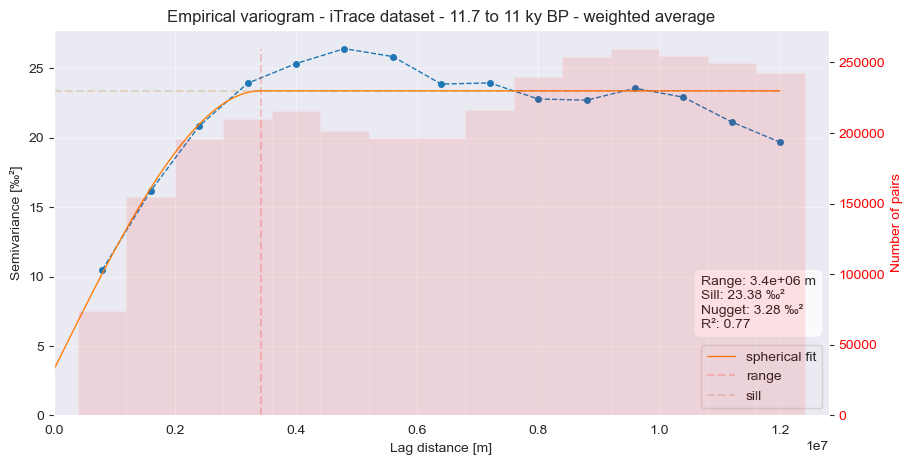

In [30]:
fig,ax = putils.plot_variogram_from_bins_and_gamma(centers=dict_dfs['i_all']['df']['lag'],
                                          gamma=dict_dfs['i_all']['df']['gamma'],
                                          time='iTrace dataset - 11.7 to 11 ky BP - weighted average',
                                          counts=dict_dfs['i_all']['df']['count'],
                                          min_pairs=20,
                                          plot_model=True,
                                          model_name=model_name,
                                          model_fct=dict_dfs['i_all']['fct_fitted'],
                                          model_params=dict_dfs['i_all']['params'],
                                          figsize=(10,5),
                                          save_name=fp+'fig.png'
                                          ) # type:ignore
plt.show()
plt.close('all')

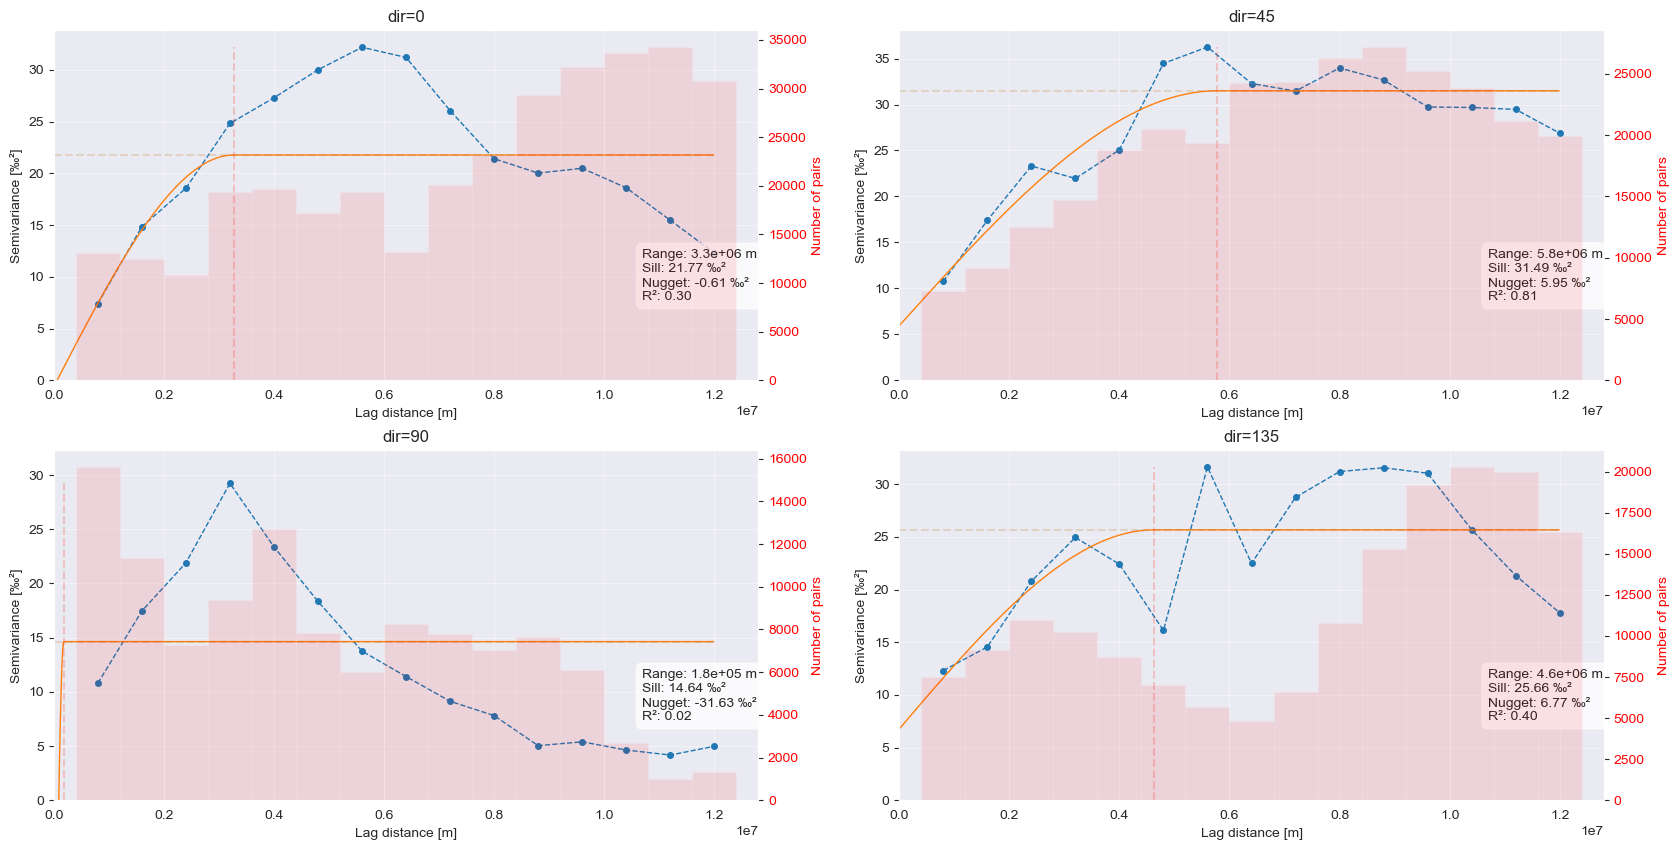

Range in direction 0°: 3.27e+06 m
Range in direction 45°: 5.77e+06 m
Range in direction 90°: 1.82e+05 m
Range in direction 135°: 4.63e+06 m
Anisotropy Ratio: 31.76764223797253
Anisotropy Direction: 45°


In [29]:
list_dir = [0,45,90,135]
ranges=[]
fig,axes = plt.subplots(2,2,figsize=(20,10))
for i in range(2):
    for j in range(2):
        key = f'i_{list_dir[j+2*i]}'
        axes[i,j] = putils.plot_variogram_from_bins_and_gamma(centers=dict_dfs[key]['df']['lag'],
                                                            gamma=dict_dfs[key]['df']['gamma'],
                                                            time='iTrace dataset - 11.7 to 11 ky BP - weighted average',
                                                            counts=dict_dfs[key]['df']['count'],
                                                            min_pairs=20,
                                                            plot_model=True,
                                                            model_name=model_name,
                                                            model_fct=dict_dfs[key]['fct_fitted'],
                                                            model_params=dict_dfs[key]['params'],
                                                            figsize=(10,5),
                                                            ax_ = axes[i,j]
                                                            #     save_name='../output/variograms/fig_global_variogram_and_model_chen.png'
                                                            ) # type:ignore
        axes[i,j].set_title(f'dir={list_dir[j+2*i]}')
        ranges.append(dict_dfs[key]['params']['range'])
        
plt.show()
plt.close('all')

for dir, r in zip(list_dir, ranges):
    print(f'Range in direction {dir}°: {r :.2e} m')
anisotropy_ratio = max(ranges) / min(ranges)
print(f'Anisotropy Ratio: {anisotropy_ratio}')
max_range_index = ranges.index(max(ranges))
print(f'Anisotropy Direction: {list_dir[max_range_index]}°')

### Visualize metrics of trend fitting 

In [34]:
import json
with open(fp+'trend_metrics.json', 'r') as f:
    results_dict = json.load(f)

In [70]:
import numpy as np
list_df =[]
metrics_dict = {}
for i,t in enumerate(list(results_dict.keys())):
    df = gutils.multiple_linear_result_dict_to_df(results_dict[t])
    df['time']=float(t)
    df['r2']=results_dict[t]['r2']
    df['r2adj']=results_dict[t]['adj_r2']
    df['mae']=results_dict[t]['mae']
    list_df.append(df)
    


result_df = pd.concat(list_df).reset_index(drop=True)

In [77]:
result_df.loc[result_df['name']=='ele',['time','beta','std_error','p_value','r2','r2adj','mae']]

,time,beta,std_error,p_value,r2,r2adj,mae
2,21.0,-0.005067,0.000058,0.0,0.883510,0.883469,3.433935
5,36521.0,-0.005256,0.000057,0.0,0.884077,0.884036,3.402237
8,73021.0,-0.005250,0.000057,0.0,0.883791,0.883750,3.407943
11,109521.0,-0.005569,0.000060,0.0,0.874035,0.873990,3.556168
14,146021.0,-0.005588,0.000060,0.0,0.873602,0.873558,3.562342
17,182521.0,-0.005558,0.000060,0.0,0.875856,0.875812,3.549041
20,219021.0,-0.005630,0.000060,0.0,0.873942,0.873898,3.566175
